In [1]:
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Adding src to path allows us to import our modular hedging functions
sys.path.append(os.path.abspath('../src'))
from hedging_utils import black_scholes, calculate_pnl

# Load data from the dedicated data folder
data_path = os.path.join('..', 'data', '20260205_option_minute_prices_expiry.csv')
df = pd.read_csv(data_path)
print("Environment initialized and data loaded.")

Environment initialized and data loaded.


### Simulation Parameters
In this section, we define the constants required for the Black-Scholes model. We focus on a single target option to establish a clear baseline before introducing more complex dynamics like stochastic volatility or transaction costs.

In [2]:
# Cell 2: Parameter Initialization with IV
from hedging_utils import implied_volatility

# 1. Define market parameters
K = 2570000.0
r = 0.00  # Futures options pricing (Black-76) requires r=0.0 since futures have zero carry cost
T = 16.0 / 365.0  # Actual time-to-expiry from Feb 5, 2026 to Feb 21, 2026 (16 days)

# 2. Extract initial market price for IV calculation
initial_market_price = df[(df['minute_end'] == 91600) & 
                          (df['symbol'] == 'NIFTY2621025700CE')]['last_trade_price'].iloc[0]
S_path = df[df['symbol'].str.contains('FUT')]['last_trade_price'].values
S_initial = S_path[0]

# 3. Calculate dynamic Sigma (IV)
sigma = implied_volatility(initial_market_price, S_initial, K, T, r, 'call')

print(f"Calculated Implied Volatility: {sigma:.4f}")

Calculated Implied Volatility: 0.0577


### Visualize Option Greeks

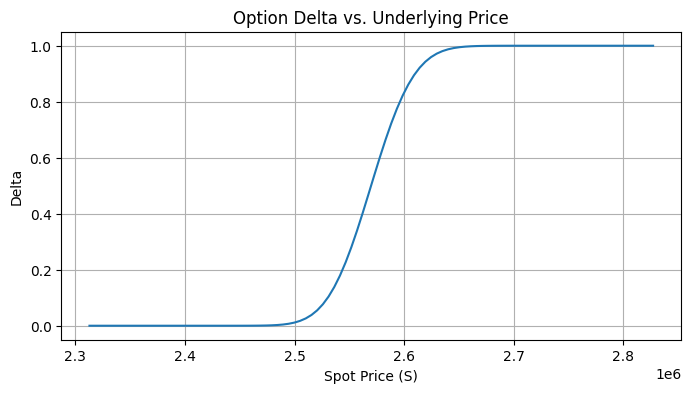

In [3]:
# We visualize how Delta changes with the underlying price (S)
S_range = np.linspace(K * 0.9, K * 1.1, 100)
deltas = [black_scholes(s, K, T, r, sigma, 'call')[1] for s in S_range]

plt.figure(figsize=(8, 4))
plt.plot(S_range, deltas, label='Call Delta')
plt.title('Option Delta vs. Underlying Price')
plt.xlabel('Spot Price (S)')
plt.ylabel('Delta')
plt.grid(True)
plt.show()

### Dynamic Delta Hedging
The following loop implements a dynamic delta hedging strategy. We rebalance the hedge position ($δ_t$) at each time step based on the Black-Scholes delta. This mimics a market maker maintaining a delta-neutral portfolio.

In [4]:
# 1. Initialize Delta sequence
delta_sequence = []

# 2. Iterate through price path to calculate Delta at every minute
for s_t in S_path:
    _, delta, _, _ = black_scholes(s_t, K, T, r, sigma, 'call')
    delta_sequence.append(delta)

# 3. Calculate the total P&L
total_pnl = calculate_pnl(np.array(delta_sequence), S_path, K, 'call')

print(f"Simulation finished.")
print(f"Total P&L for this path: {total_pnl:.2f}")

Simulation finished.
Total P&L for this path: -6640.48


### Strategy Performance Dashboard

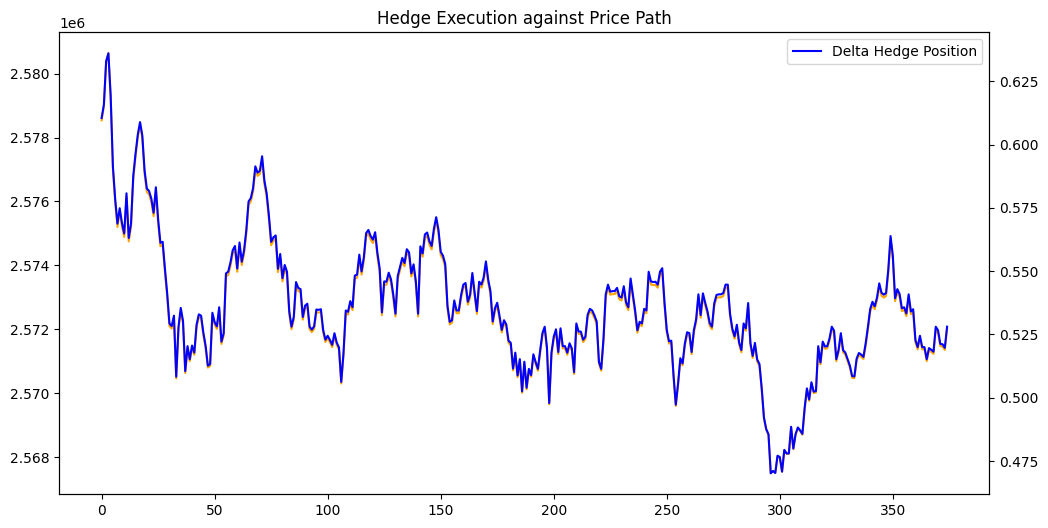

,Total P&L,Mean Delta,Final Volatility Assumption
0,-6640.480139,0.535959,0.057693


In [5]:
from hedging_utils import calculate_cvar

# 1. Visualize Delta vs. Price Overlay
plt.figure(figsize=(12, 6))
plt.plot(S_path, label='Future Price (S)', color='orange')
plt.twinx()
plt.plot(delta_sequence, label='Delta Hedge Position', color='blue')
plt.title('Hedge Execution against Price Path')
plt.legend()
plt.show()

# 2. Add a Summary Table
results = {
    "Total P&L": total_pnl,
    "Mean Delta": np.mean(delta_sequence),
    "Final Volatility Assumption": sigma
}
results_df = pd.DataFrame([results])
display(results_df)